# Data5441 - Networks and High-dimensional Inference 
Semester 2, 2026


# Tutorial Week 5

This notebook contains code and driving questions for your work. You're encouraged to perform your calculations, explorations, and estimations here, using the results you obtain to answer the questions in the accompanying assignment. 


In [27]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import poisson
import networkx as nx

SEED = 5441

The goal of this tutorial is to investigate random network models that aim to explain the origin of ubiquitous observations in complex networks:

1. To explain the combination of high clustering and short distances in sparse networks, we consider models of the small-world phenomenon inspired by the Watts–Strogatz model.
2. To explain the high-degree variability observed in many networks, we investigate the Barabási–Albert preferential-attachment model.


# 1. Small-world phenomenon

A network is considered small-world if it is sparse and combines short distances between pairs of nodes with high clustering. For a sequence of random graph models with $N \rightarrow \infty$, one useful asymptotic criterion is that typical distances grow approximately logarithmically with $N$, or comparably to those in a suitable random-graph baseline, while clustering remains nonzero or much larger than in that baseline. A paradigmatic model explaining the onset of these properties is the Watts–Strogatz model, which is constructed using the following two steps:

- The starting network $g_0$ is a ring in which each node is connected to its $k$ nearest neighbours in total ($k/2$ on each side, so we use an even $k$).
- Each edge is rewired with probability $p$.

The plots below illustrate the resulting networks for increasing values of $p$.


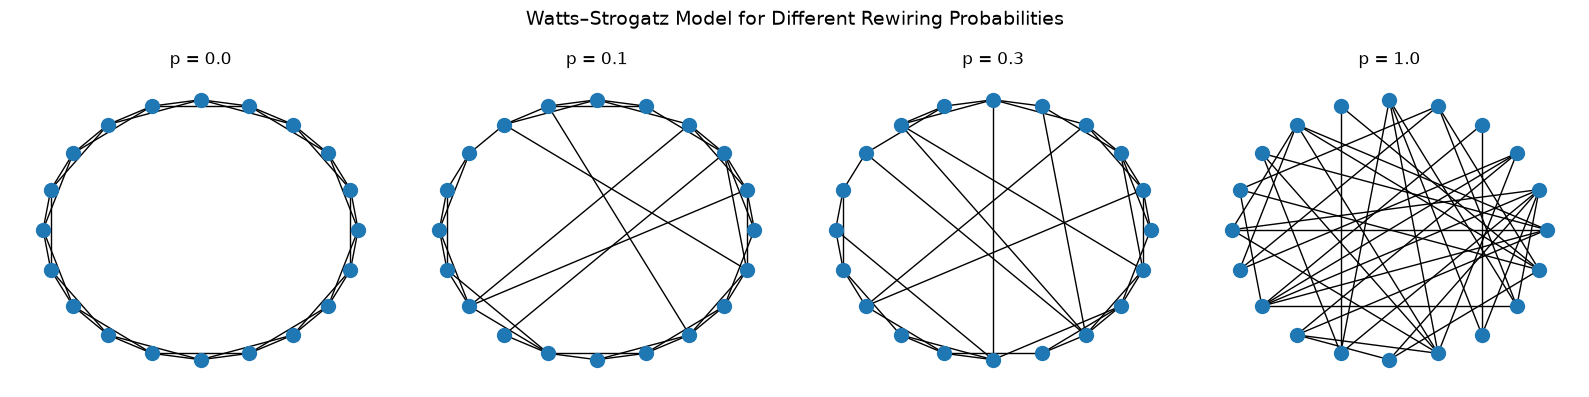

In [28]:
# Parameters
N = 20     # Number of nodes (small for visualization)
k = 4      # Each node is connected to k nearest neighbours in total
p_values = [0.0, 0.1, 0.3, 1.0]  # Rewiring probabilities

# Layout for consistent node positions
pos = nx.circular_layout(range(N))

# Plotting
fig, axes = plt.subplots(1, len(p_values), figsize=(16, 4))
fig.suptitle("Watts–Strogatz Model for Different Rewiring Probabilities", fontsize=14)

for ax, p in zip(axes, p_values):
    G = nx.watts_strogatz_graph(N, k, p, seed=SEED)
    nx.draw(G, pos=pos, ax=ax, node_size=100, with_labels=False)
    ax.set_title(f"p = {p}")

plt.tight_layout()
plt.show()


We now characterize the small-world phenomenon in Watts–Strogatz models by studying how the global clustering coefficient $C_{net}$, the diameter $d_{\mathrm{diam}}$, and the average shortest-path length $\langle\langle d\rangle\rangle$ depend on $p$ and $N$.


In [29]:
# Parameters
N = 200          # Number of nodes
k = 4            # Each node is connected to k nearest neighbours in total
p_values = np.logspace(-4, 0, 50)  # Rewiring probabilities from 0.0001 to 1

clustering = []
diameters = []
distances = []


for sample_index, p in enumerate(p_values):
    G = nx.watts_strogatz_graph(N, k, p, seed=SEED + sample_index)
    
    # Global clustering coefficient
    C = nx.transitivity(G)
    clustering.append(C)
    
    # Diameter and average shortest-path length
    if nx.is_connected(G):
        d_diam = nx.diameter(G)
        d_average = nx.average_shortest_path_length(G)
    else:
        # Use the largest connected component for both distance measures
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        d_diam = nx.diameter(subgraph)
        d_average = nx.average_shortest_path_length(subgraph)
    diameters.append(d_diam)
    distances.append(d_average)


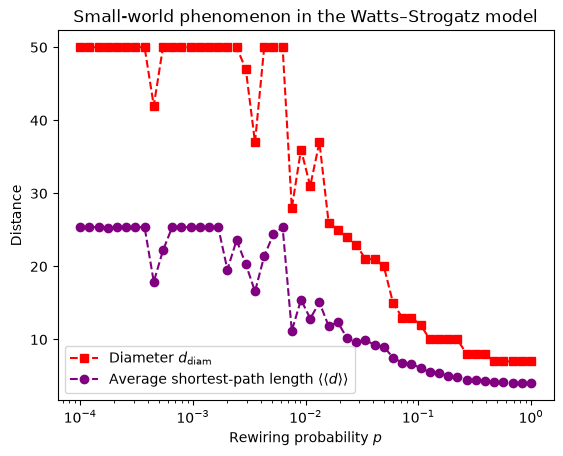

In [30]:
plt.plot(p_values, diameters, 's--', color='red', label=r'Diameter $d_{\mathrm{diam}}$')
plt.plot(p_values, distances, 'o--', color='purple', label=r'Average shortest-path length $\langle\langle d\rangle\rangle$')
plt.xscale("log")
plt.ylabel('Distance')
plt.xlabel('Rewiring probability $p$')
plt.title('Small-world phenomenon in the Watts–Strogatz model')
plt.legend()
plt.show()


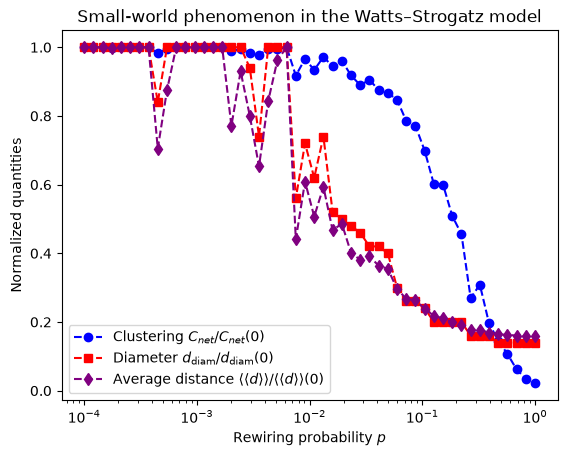

In [31]:
# p=0 reference values
G = nx.watts_strogatz_graph(N, k, p=0, seed=SEED)
C0 = nx.transitivity(G)
d_diam0 = nx.diameter(G)
d_average0 = nx.average_shortest_path_length(G)


plt.plot(p_values, np.array(clustering) / C0, 'o--', color='blue', label=r'Clustering $C_{net}/C_{net}(0)$')
plt.plot(p_values, np.array(diameters) / d_diam0, 's--', color='red', label=r'Diameter $d_{\mathrm{diam}}/d_{\mathrm{diam}}(0)$')
plt.plot(p_values, np.array(distances) / d_average0, 'd--', color='purple', label=r'Average distance $\langle\langle d\rangle\rangle/\langle\langle d\rangle\rangle(0)$')
plt.xscale("log")
plt.ylabel('Normalized quantities')
plt.xlabel('Rewiring probability $p$')
plt.title('Small-world phenomenon in the Watts–Strogatz model')
plt.legend()
plt.show()


## Exercise 1.1. Small-world behavior in the Watts–Strogatz model
- Increase the value of $N$ in the computation above and observe what happens to the curves.
- For which values of $p$ in the figure is the network small-world?


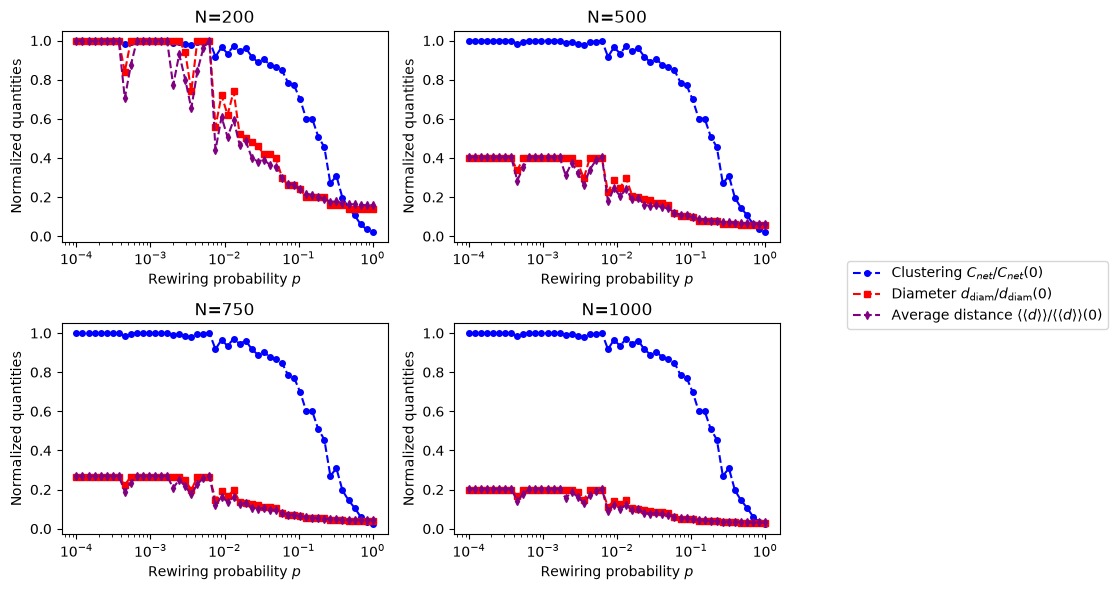

In [32]:
# Parameters
Ns = [200, 500, 750, 1000]  # Number of nodes
k = 4  # Each node is connected to k nearest neighbours in total
p_values = np.logspace(-4, 0, 50)  # Rewiring probabilities from 0.0001 to 1

fig, axs = plt.subplots(2, 2, figsize=(8, 6))

for i, N in enumerate(Ns):
    # p=0 reference values
    G = nx.watts_strogatz_graph(N, k, p=0, seed=SEED)
    C0 = nx.transitivity(G)
    d_diam0 = nx.diameter(G)
    d_average0 = nx.average_shortest_path_length(G)

    axs[i // 2, i % 2].plot(p_values, np.array(clustering) / C0, 'o--', color='blue',
                            label=r'Clustering $C_{net}/C_{net}(0)$', markersize=4)
    axs[i // 2, i % 2].plot(p_values, np.array(diameters) / d_diam0, 's--', color='red',
                            label=r'Diameter $d_{\mathrm{diam}}/d_{\mathrm{diam}}(0)$', markersize=4)
    axs[i // 2, i % 2].plot(p_values, np.array(distances) / d_average0, 'd--', color='purple',
                            label=r'Average distance $\langle\langle d\rangle\rangle/\langle\langle d\rangle\rangle(0)$', markersize=4)
    axs[i // 2, i % 2].set_xscale("log")
    axs[i // 2, i % 2].set_ylabel('Normalized quantities')
    axs[i // 2, i % 2].set_xlabel('Rewiring probability $p$')
    axs[i // 2, i % 2].set_title(f'N={N}')

handles, labels = axs[i // 2, i % 2].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.4, 0.5))

plt.tight_layout()
plt.show()

## Exercise 1.2. Small-world behavior under edge swaps

- As the starting network $g_0$, we consider the $M$ by $M$ square lattice studied in Week 2 (code below).
- We then modify $g_0$ by performing $t$ edge-swap moves (as discussed in Week 4), obtaining $g(t)$.

```
nx.double_edge_swap(g)
```

a) Compute how $C_{net}$ and $d_{\mathrm{diam}}$ depend on $t$ for $M=10$ and $t=0,1, \ldots, t_{max}>t_{equilibration}$.

b) Using normalized variables analogous to those used above for the Watts–Strogatz model, plot $C_{net}/C_{net}(0)$ and $d_{\mathrm{diam}}/d_{\mathrm{diam}}(0)$ against $2t/L$ for $M=10,30,50$. Each swap updates two of the $L$ edges, so $2t/L$ is the normalized number of edge updates.

c) Discuss the region of the previous plot in which the small-world phenomenon is observed. What happens to this region as $M\rightarrow\infty$?


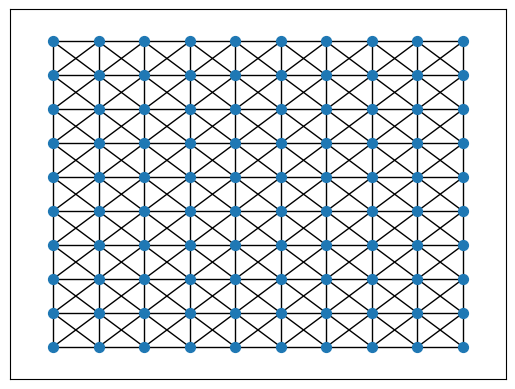

In [33]:
def T3(g, rng, nswap=1):
    nx.double_edge_swap(
        g,
        nswap=nswap,
        max_tries=max(100, 20 * nswap),
        seed=int(rng.integers(0, 2**32 - 1))
    )
    return g

def run_simulation(gs, transf_func, seed, tmax=100, step=10):
    g = gs.copy()
    rng = np.random.default_rng(seed)

    outs = []

    N0 = g.number_of_nodes()
    L0 = g.number_of_edges()
    degree_sequence0 = dict(g.degree())

    for i in range(tmax):
        t = i * step

        outs.append([t, g.number_of_edges(), nx.diameter(g), nx.transitivity(g)])

        g = transf_func(g, rng, nswap=step)

        assert g.number_of_nodes() == N0
        assert g.number_of_edges() == L0
        assert dict(g.degree()) == degree_sequence0
        assert nx.number_of_selfloops(g) == 0
        assert nx.is_connected(g)

    output = pd.DataFrame(outs, columns=["time", "edges", "diameter", "transitivity"])

    output["normalised_time"] = 2 * output["time"] / L0
    output["diameter_ratio"] = (output["diameter"] / output["diameter"].iloc[0])
    output["transitivity_ratio"] = (output["transitivity"] / output["transitivity"].iloc[0])

    return output


def generate_lattice(M):
    """Generate an M by M square lattice with nearest-neighbour and diagonal edges."""
    G = nx.Graph()

    for i in range(M):
        for j in range(M):
            G.add_node((i, j))

            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:

                    if di == 0 and dj == 0:
                        continue

                    ni = i + di
                    nj = j + dj

                    if 0 <= ni < M and 0 <= nj < M:
                        G.add_edge((i, j), (ni, nj))

    return G


M = 10
g0 = generate_lattice(M)
pos = {(i, j): (j, -i) for i in range(M) for j in range(M)}  # Position nodes in a grid
nx.draw_networkx(g0, pos=pos, node_size=50, with_labels=False)

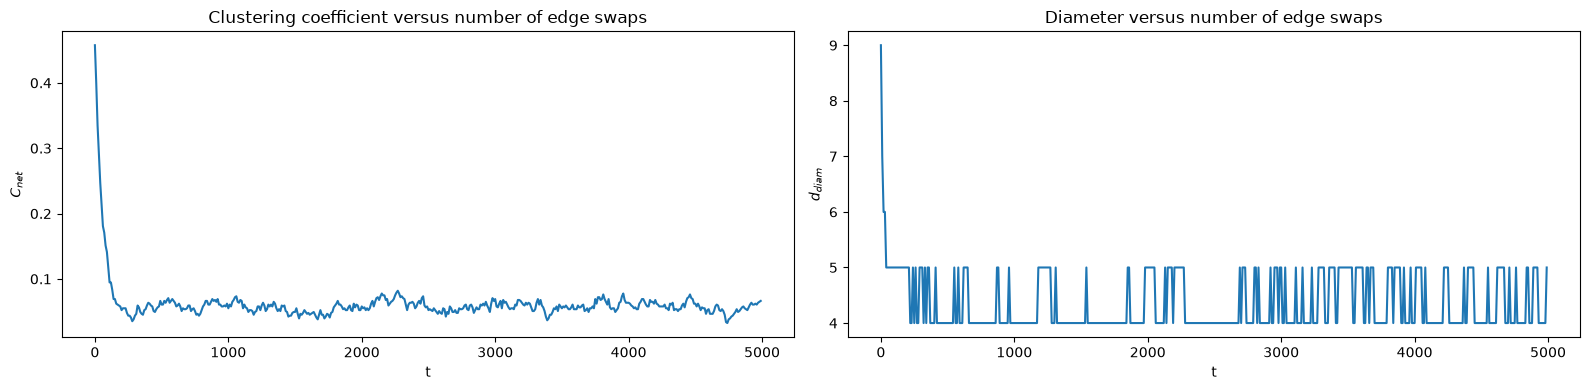

In [34]:
M = 10
g0 = generate_lattice(M)

output = run_simulation(g0, transf_func=T3, seed=SEED, tmax=500, step=10)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
ax[0].plot(output["time"], output["transitivity"])
ax[0].set_xlabel("t")
ax[0].set_ylabel(r"$C_{net}$")
ax[0].set_title("Clustering coefficient versus number of edge swaps")

ax[1].plot(output["time"], output["diameter"])
ax[1].set_xlabel("t")
ax[1].set_ylabel(r"$d_{diam}$")
ax[1].set_title("Diameter versus number of edge swaps")

plt.tight_layout()
plt.show()

In [35]:
Ms = [10, 30, 50]
xmax = 3
n_measurements = 60

RUN = False
OUTPUT_DIR = Path("outputs")
results = {}

if RUN:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    for M in Ms:
        g = generate_lattice(M)
        L = g.number_of_edges()

        total_swaps = int(xmax * L / 2)

        step = max(1, int(np.ceil(total_swaps / (n_measurements - 1))))
        n_records = int(np.ceil(total_swaps / step)) + 1

        output = run_simulation(g,transf_func=T3,seed=SEED,tmax=n_records,step=step)

        results[M] = output

        output_file = OUTPUT_DIR / f"lattice_M{M}.csv"
        output.to_csv(output_file, index=False)
else:
    for M in Ms:
        output_file = OUTPUT_DIR / f"lattice_M{M}.csv"
        results[M] = pd.read_csv(output_file)

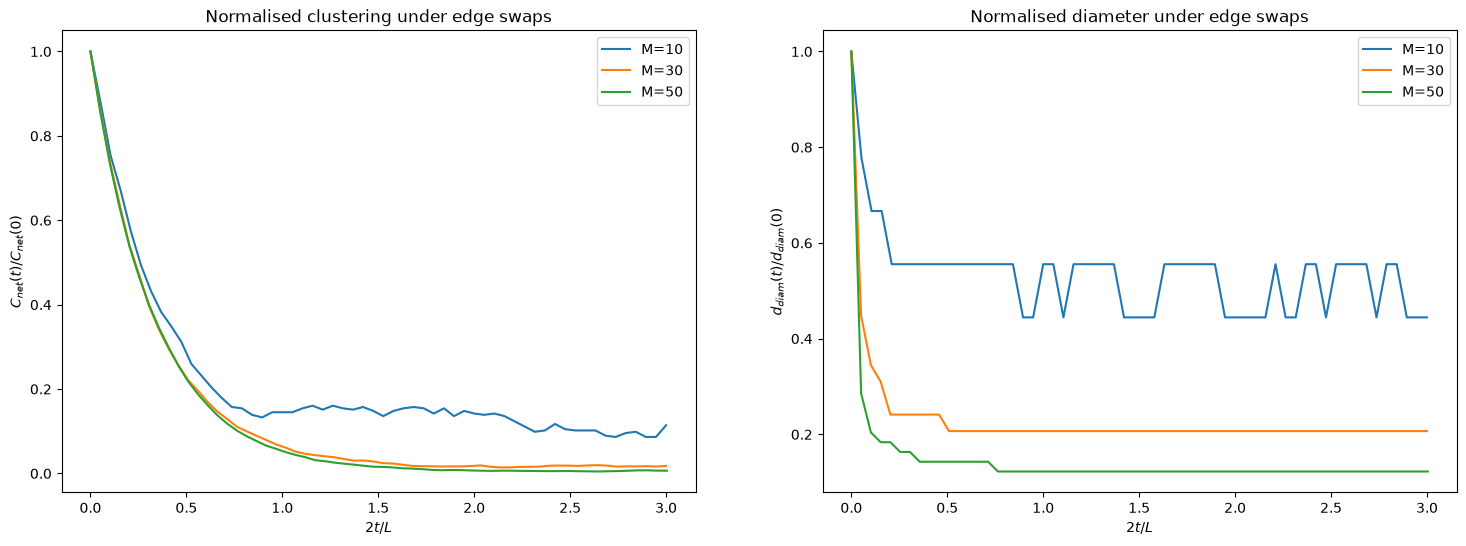

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

for M, output in results.items():
    ax[0].plot(output["normalised_time"], output["transitivity_ratio"], label=f"M={M}")
    ax[1].plot(output["normalised_time"], output["diameter_ratio"], label=f"M={M}")


ax[0].set_xlabel(r"$2t/L$")
ax[0].set_ylabel(r"$C_{net}(t)/C_{net}(0)$")
ax[0].set_title("Normalised clustering under edge swaps")
ax[0].legend()

ax[1].set_xlabel(r"$2t/L$")
ax[1].set_ylabel(r"$d_{diam}(t)/d_{diam}(0)$")
ax[1].set_title("Normalised diameter under edge swaps")
ax[1].legend()

plt.show()

# 2. The preferential-attachment model $G_{ba}(m, N)$

In this mechanistic random-graph model, at each time $t$ a node is added to the network with $m$ edges. Each edge is attached to an existing node $i$ with probability
$$
\pi_i = \frac{z_i}{2L},
$$
with a small network of a few nodes used as an initial condition. The process is repeated until the network reaches $N$ nodes.


The NetworkX implementation is
> `nx.barabasi_albert_graph(N, m)`

and more can be learned by running

> `help(nx.barabasi_albert_graph)`


# Visualization

The code below generates realizations of $G_{ba}(m,N)$ for increasing values of $N \in \{5,10,20,50,100\}$ and $m=1$. Notice that each plot is a new, independent realization of the Barabási–Albert random-graph model.


N is 5 and m is 1


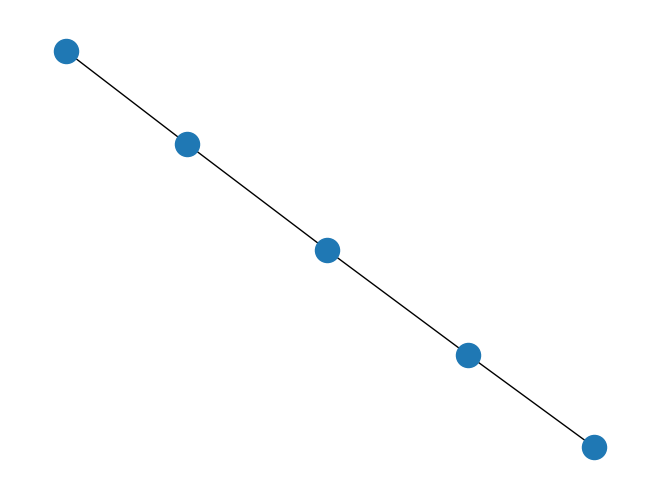

N is 10 and m is 1


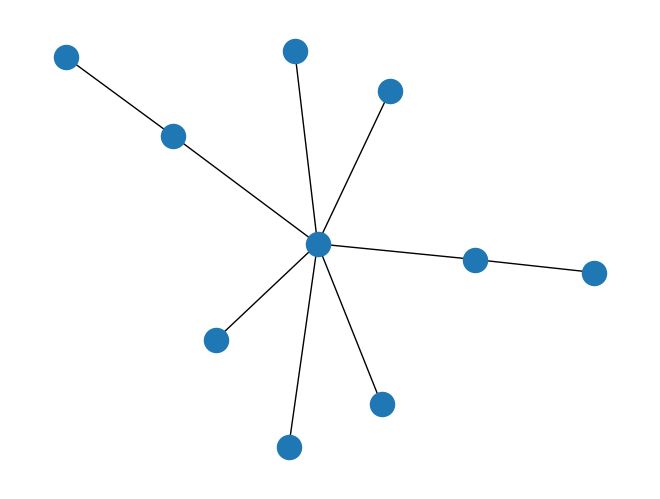

N is 20 and m is 1


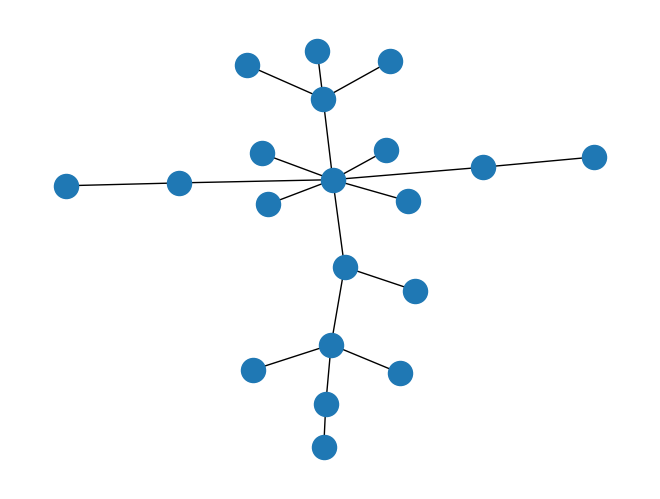

N is 50 and m is 1


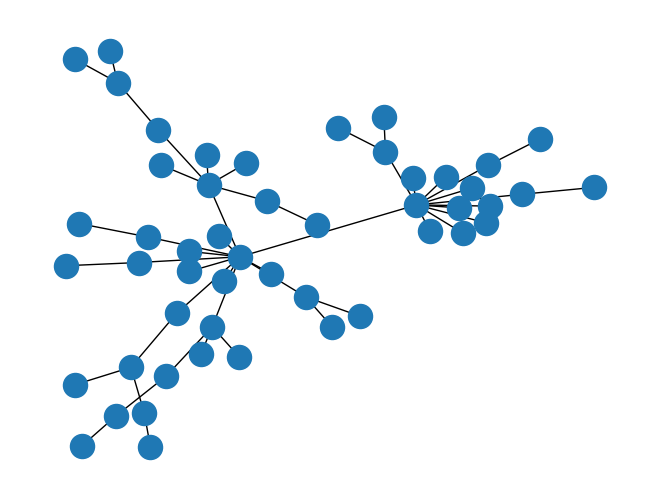

N is 100 and m is 1


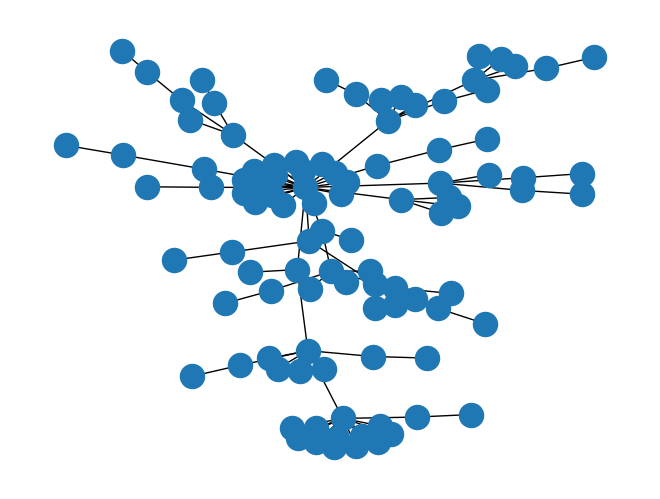

In [37]:
n_values = [5, 10, 20, 50, 100]
m = 1

for n in n_values:
    gba = nx.barabasi_albert_graph(n, m, seed=SEED + n)
    print(f"N is {n} and m is {m}")
    plt.figure()
    pos = nx.spring_layout(gba, seed=SEED)
    nx.draw(gba, pos=pos)
    plt.show()


## Exercise 2.1. Preferential-attachment model versus Poisson random graph

Here we compare the properties of the Poisson random-graph model $G_P(p,N)$ with those of $G_{ba}(m,N)$. The models have the same $N$, and $p$ is chosen so that the expected number of edges in $G_P$ approximately matches the number of edges in $G_{ba}$ for large $N$. The questions below guide the analysis used in the accompanying assignment.

(a) What value of $m$ should be chosen in the preferential-attachment model to generate random graphs suitable for comparison with a network of average degree $\langle z \rangle$?

(b) Compute the approximate relationship between $p$ and $m$ needed to ensure that $G_P(p,N)$ and $G_{ba}(m,N)$ have the same $N$ and approximately the same expected number of edges for large $N$.

(c) Plot a network generated from $G_{ba}(m,N)$ for $m=1$ and $N=30$ and the corresponding Poisson random graph with the same $N$ and approximately the same expected number of edges. Identify the main visual differences between these graphs.

(d) For $N=1000$ and $m=1,2,\ldots,9$, compute histograms of the degree distributions for $G_{ba}$ and the corresponding $G_P$. Examine the effect of using logarithmic scales on the $x$- and $y$-axes.

(e) For the two network models

- $G_{ba}$ with $m=4$;
- $G_P$ fitted approximately to $G_{ba}$ by matching $N$ and the expected number of edges,

compute how

- the average shortest-path length $\langle \langle d \rangle \rangle$,
- the clustering coefficient $C_{net}$,
- and the degree variability $\sigma_z/\langle z \rangle$

change as $N$ increases (e.g., $N \in [10,20,100,200,1000]$).

Using the numerical results, compare $G_{ba}$ with $G_P$ and reflect on the extent to which BA networks account for characteristics of complex networks discussed in class that are absent from Poisson random graphs.


In [38]:
# Some Utils
def matched_poisson_probability(N, m):
    return 2 * m / (N - 1)

def degree_statistics(g):
    degrees = np.array([d for _, d in g.degree()], dtype=float)

    mean_degree = degrees.mean()
    std_degree = degrees.std(ddof=0)
    relative_variability = std_degree / mean_degree

    return mean_degree, std_degree, relative_variability


def average_shortest_path_connected_component(g):
    if nx.is_connected(g):
        return nx.average_shortest_path_length(g)
    largest_cc_nodes = max(nx.connected_components(g), key=len)
    largest_cc = g.subgraph(largest_cc_nodes)
    return nx.average_shortest_path_length(largest_cc)


def network_statistics(g):
    mean_degree, std_degree, relative_variability = degree_statistics(g)

    return {
        "N": g.number_of_nodes(),
        "L": g.number_of_edges(),
        "mean_degree": mean_degree,
        "std_degree": std_degree,
        "relative_variability": relative_variability,
        "clustering": nx.transitivity(g),
        "average_shortest_path": average_shortest_path_connected_component(g),
        "connected": nx.is_connected(g)
    }

def empirical_degree_distribution(g):
    degrees = np.array([d for _, d in g.degree()])

    values, counts = np.unique(degrees, return_counts=True)
    probabilities = counts / counts.sum()

    return values, probabilities

Part (A)

Recall that $L \approx mN$ and $\langle z \rangle = 2L/N \approx 2m$. So
$$
m \approx \frac{\langle z \rangle}{2}
$$

In [39]:
def choose_m_from_mean_degree(mean_degree):
    return int(round(mean_degree / 2))

Part (B)

In [40]:
# ER Expected number of edges: p * n * (n - 1) / 2
# BA Expected number of edges: m * n
# So p = 2 * m / (n - 1) for the same expected number of edges in both models

Part (C)

N = 30, m = 1, matched p = 0.0690, BA edges = 29, Poisson edges = 33


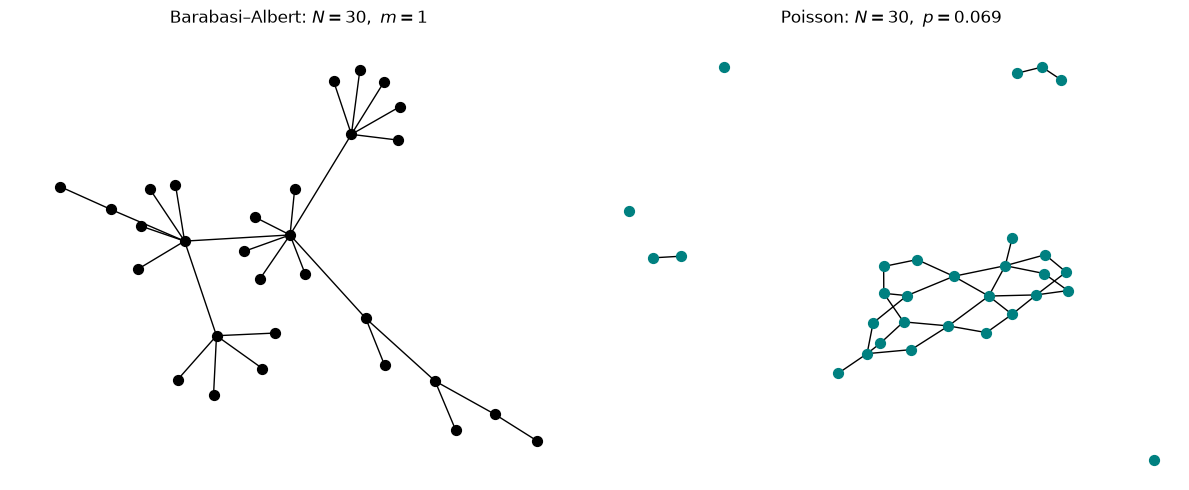

In [41]:
N = 30
m = 1

p = matched_poisson_probability(N, m)
g_ba = nx.barabasi_albert_graph(N, m, seed=SEED)
g_p = nx.erdos_renyi_graph(N, p, seed=SEED)

print(f"N = {N}, m = {m}, matched p = {p:.4f}, BA edges = {g_ba.number_of_edges()}, Poisson edges = {g_p.number_of_edges()}")





fig, axs = plt.subplots(1, 2, figsize=(12, 5))

pos_ba = nx.spring_layout(g_ba, seed=SEED)
pos_p = nx.spring_layout(g_p, seed=SEED)

nx.draw(g_ba, pos=pos_ba, ax=axs[0], node_size=50, node_color="black", with_labels=False)
nx.draw(g_p, pos=pos_p, ax=axs[1], node_size=50, node_color="teal", with_labels=False)

axs[0].set_title(r"Barabasi–Albert: $N=30,\ m=1$")
axs[1].set_title(rf"Poisson: $N=30,\ p={p:.3f}$")

plt.tight_layout()
plt.show()

Part (D)

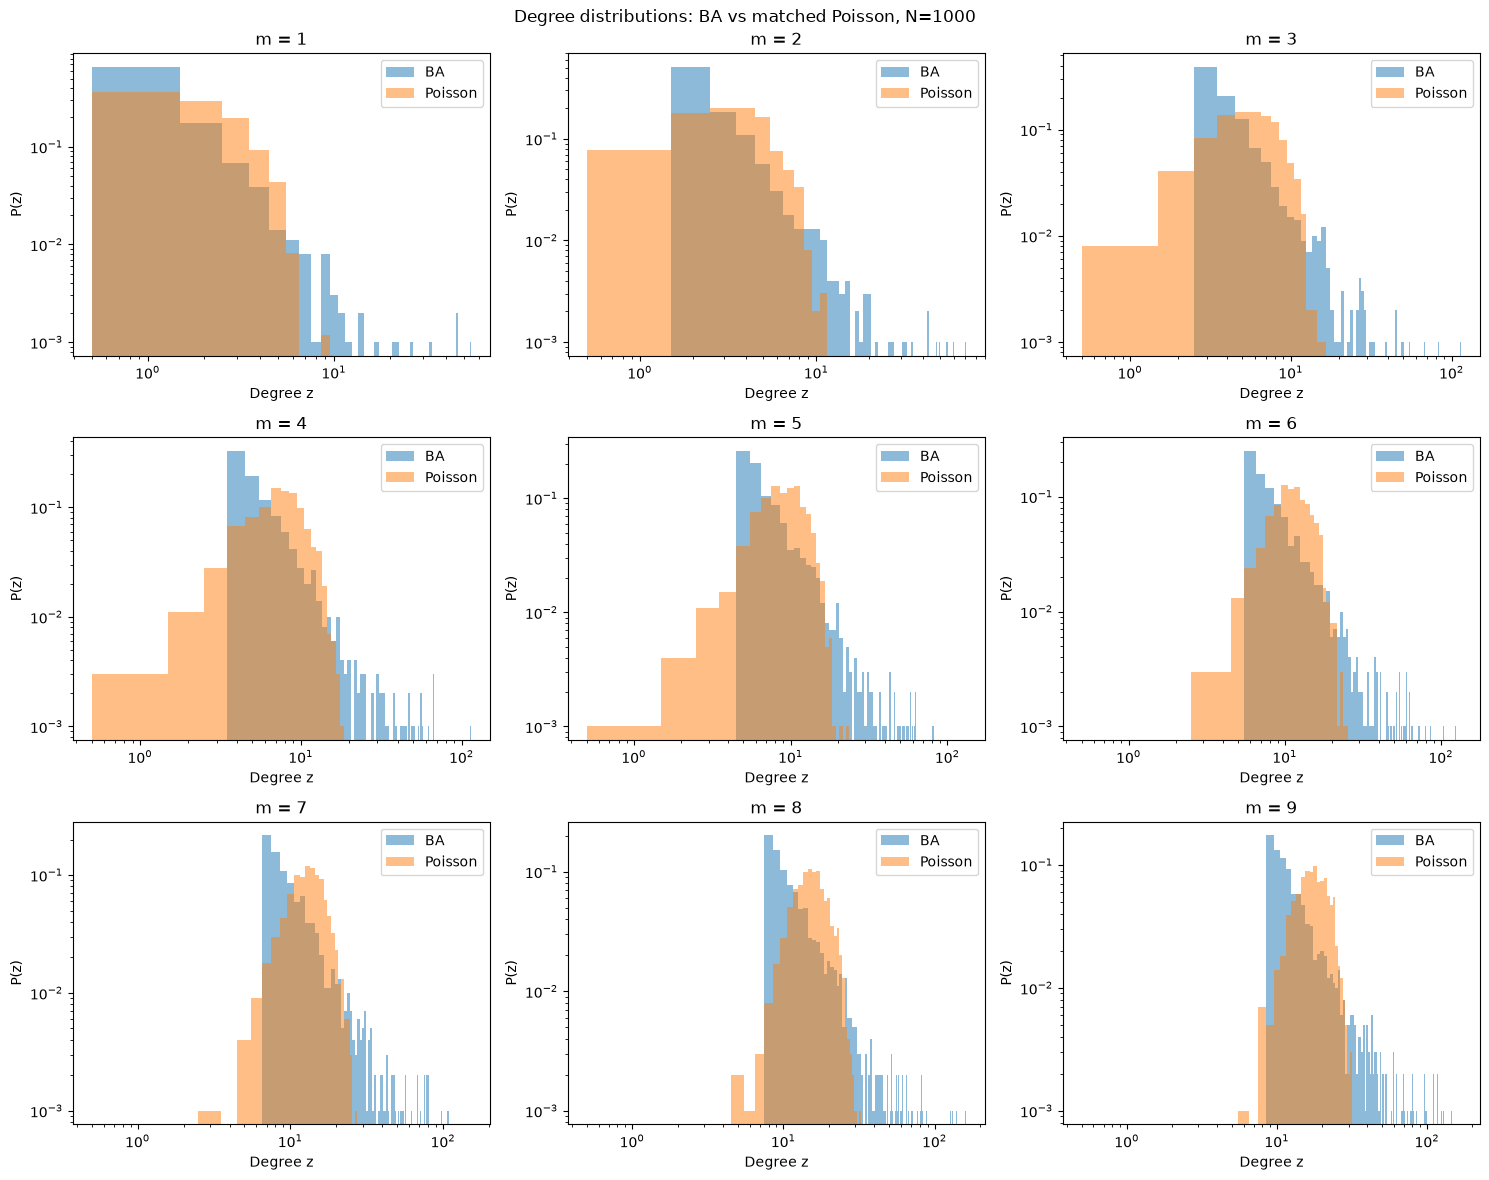

In [42]:
N = 1000
ms = range(1, 10)

degree_results = {}

for m in ms:
    p = matched_poisson_probability(N, m)

    g_ba = nx.barabasi_albert_graph(N,m, seed=SEED + m)
    g_p = nx.erdos_renyi_graph(N, p, seed=SEED + 100 + m)

    ba_degrees = np.array([d for _, d in g_ba.degree()])
    p_degrees = np.array([d for _, d in g_p.degree()])

    degree_results[m] = {"p": p, "ba": ba_degrees, "poisson": p_degrees}


LOGLOG = True

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

for ax, m in zip(axs.flat, ms):
    ba_degrees = degree_results[m]["ba"]
    p_degrees = degree_results[m]["poisson"]

    if LOGLOG:
        ba_plot = ba_degrees[ba_degrees > 0]
        p_plot = p_degrees[p_degrees > 0]
    else:
        ba_plot = ba_degrees
        p_plot = p_degrees

    max_degree = max(ba_plot.max(), p_plot.max())
    bins = np.arange(0.5, max_degree + 1.5, 1)

    ax.hist(ba_plot, bins=bins, density=True, alpha=0.5, label="BA")
    ax.hist(p_plot, bins=bins, density=True, alpha=0.5, label="Poisson")

    if LOGLOG:
        ax.set_xscale("log")
        ax.set_yscale("log")

    ax.set_title(f"m = {m}")
    ax.set_xlabel("Degree z")
    ax.set_ylabel("P(z)")
    ax.legend()

scale_label = "log-log" if LOGLOG else "linear"

plt.suptitle(f"Degree distributions: BA vs matched Poisson, N={N}")

plt.tight_layout()
plt.show()

Part (E)

In [43]:
Ns = [10, 20, 100, 200, 1000]
m = 4

rows = []

RUN = False
OUTPUT_DIR = Path("outputs")


if RUN:
    OUTPUT_DIR.mkdir(exist_ok=True)

    for N in Ns:
        p = matched_poisson_probability(N, m)

        g_ba = nx.barabasi_albert_graph(N, m, seed=SEED + N)
        g_p = nx.erdos_renyi_graph(N, p, seed=SEED + 1000 + N)

        stats_ba = network_statistics(g_ba)
        stats_p = network_statistics(g_p)

        rows.append({"N": N, "model": "BA", "p": np.nan, **stats_ba})
        rows.append({"N": N, "model": "Poisson", "p": p, **stats_p})

    results_df = pd.DataFrame(rows)
    results_df.to_csv(OUTPUT_DIR / "ba_vs_poisson_statistics.csv", index=False)
else:
    results_df = pd.read_csv(OUTPUT_DIR / "ba_vs_poisson_statistics.csv")


results_df

,N,model,p,L,mean_degree,std_degree,relative_variability,clustering,average_shortest_path,connected
0,10,BA,NaN,24,4.800,1.400000,0.291667,0.504950,1.488889,True
1,10,Poisson,0.888889,37,7.400,1.113553,0.150480,0.802469,1.177778,True
2,20,BA,NaN,64,6.400,2.782086,0.434701,0.375887,1.721053,True
3,20,Poisson,0.421053,87,8.700,1.452584,0.166964,0.438495,1.542105,True
4,100,BA,NaN,384,7.680,5.912495,0.769856,0.123116,2.357980,True
5,100,Poisson,0.080808,400,8.000,3.039737,0.379967,0.094727,2.441010,True
6,200,BA,NaN,784,7.840,6.796646,0.866919,0.082649,2.623317,True
7,200,Poisson,0.040201,788,7.880,2.730494,0.346509,0.039890,2.784975,True
8,1000,BA,NaN,3984,7.968,8.088447,1.015116,0.021630,3.214867,True
9,1000,Poisson,0.008008,3952,7.904,2.766367,0.349996,0.008100,3.577303,False


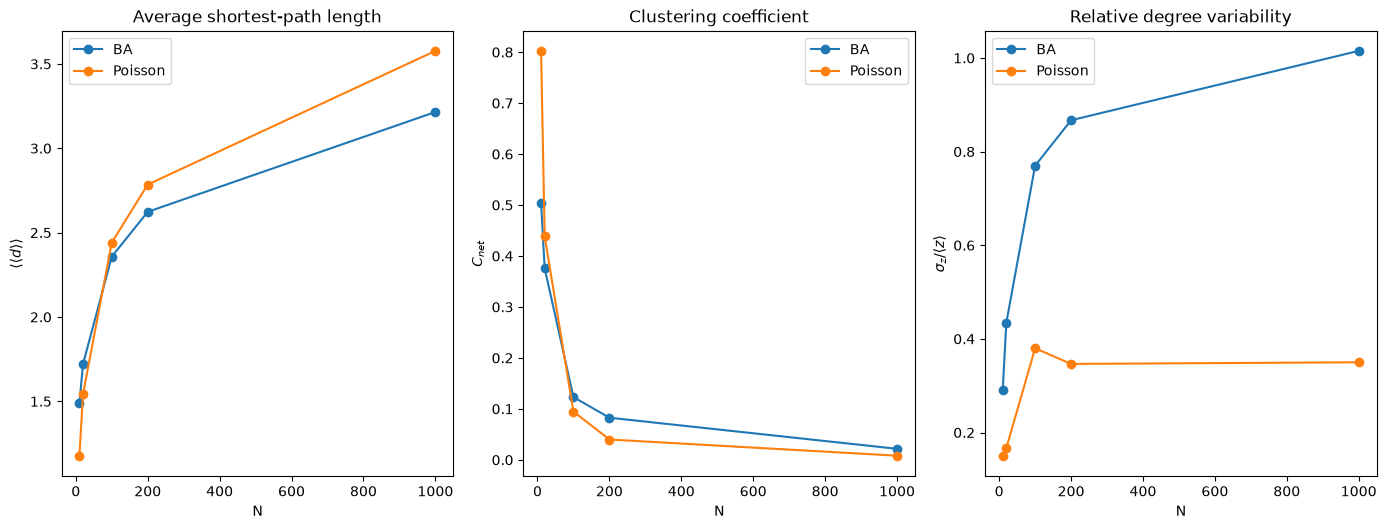

In [71]:
fig = plt.figure(figsize=(14, 10))  
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)

for model in ["BA", "Poisson"]:
    subset = results_df[results_df["model"] == model]
    ax1.plot(subset["N"], subset["average_shortest_path"], marker="o", label=model)

# ax1.set_xscale("log")
ax1.set_xlabel("N")
ax1.set_ylabel(r"$\langle\langle d\rangle\rangle$")
ax1.set_title("Average shortest-path length")
ax1.legend()

for model in ["BA", "Poisson"]:
    subset = results_df[results_df["model"] == model]
    ax2.plot(subset["N"], subset["clustering"], marker="o", label=model)

# ax2.set_xscale("log")
ax2.set_xlabel("N")
ax2.set_ylabel(r"$C_{net}$")
ax2.set_title("Clustering coefficient")
ax2.legend()

for model in ["BA", "Poisson"]:
    subset = results_df[results_df["model"] == model]
    ax3.plot(subset["N"], subset["relative_variability"], marker="o", label=model)

# ax3.set_xscale("log")
ax3.set_xlabel("N")
ax3.set_ylabel(r"$\sigma_z/\langle z\rangle$")
ax3.set_title("Relative degree variability")
ax3.legend()

plt.tight_layout()
plt.show()

## Exercise 2.2. Degree variability in an empirical network

In this exercise, we analyze the network of hyperlinks between political blogs stored in `data/out.moreno_blogs_blogs`. Treat the data as a simple undirected network by removing self-loops.

(a) Compute the number of nodes $N$, the number of edges $L$, the average degree $\langle z\rangle$, the standard deviation $\sigma_z$, and the relative degree variability $\sigma_z/\langle z\rangle$.

(b) For a Poisson degree distribution, the expected relative variability is approximately
$$
\frac{\sigma_z}{\langle z\rangle}=\frac{1}{\sqrt{\langle z\rangle}}.
$$
Compare this benchmark with the empirical result and with an Erdos-Renyi random graph fitted to the network. What does the comparison indicate about the degree variability and the tail of the empirical distribution?

(c) Fit a Barabási–Albert preferential-attachment model to the data by setting $N$ equal to the empirical number of nodes and choosing the integer $m$ closest to the expected number of edges. Generate a realization using these parameters and compute its $\sigma_z/\langle z\rangle$. How does its relative degree variability compare with the empirical and Poisson results?

(d) Plot the empirical degree distribution $P(z)$ using both linear and log–log axes. On both plots, include the Poisson distribution with mean $\langle z\rangle$ as a reference.

(e) Produce the same two degree-distribution plots, now comparing the empirical network with one realization of an Erdős–Rényi graph and one realization of the Barabási–Albert model, both fitted to the data.


In [45]:
# Load the political-blogs network as a simple undirected graph.
Gblogs = nx.read_edgelist(
    "./out.moreno_blogs_blogs",
    nodetype=int,
    create_using=nx.Graph(),
)
Gblogs.remove_edges_from(nx.selfloop_edges(Gblogs))


In [47]:
def degree_statistics(g):
    """
    Compute N, L, mean degree, degree standard deviation,
    and relative degree variability.
    """
    degrees = [d for _, d in g.degree()]
    N = g.number_of_nodes()
    L = g.number_of_edges()

    mean_degree = np.mean(degrees)
    sigma_degree = np.std(degrees, ddof=0)

    relative_variability = sigma_degree / mean_degree

    return {
        "N": N,
        "L": L,
        "mean_degree": mean_degree,
        "sigma_degree": sigma_degree,
        "relative_variability": relative_variability,
    }


def empirical_degree_distribution(g):
    degrees = [d for _, d in g.degree()]
    counts = np.bincount(degrees)

    z = np.arange(len(counts))
    Pz = counts / counts.sum()

    return z, Pz


def poisson_degree_distribution(mean_degree, max_degree):
    """
    Compute Poisson probabilities P(z) for z = 0,...,max_degree.
    """
    z = np.arange(max_degree + 1)
    Pz = poisson.pmf(z, mu=mean_degree)

    return z, Pz

Part (A)

In [50]:
empirical_stats = degree_statistics(Gblogs)

print(f"N = {empirical_stats['N']}")
print(f"L = {empirical_stats['L']}")
print(f"<z> = {empirical_stats['mean_degree']:.6f}")
print(f"sigma_z = {empirical_stats['sigma_degree']:.6f}")
print(f"degree variability = {empirical_stats['relative_variability']:.6f}")

N = 1224
L = 16715
<z> = 27.312092
sigma_z = 38.384842
degree variability = 1.405416


Part (B)

In [57]:
N_emp = empirical_stats["N"]
L_emp = empirical_stats["L"]
mean_degree_emp = empirical_stats["mean_degree"]

poisson_relative_variability = 1 / np.sqrt(mean_degree_emp)
p_er = mean_degree_emp / (N_emp - 1)


G_er = nx.erdos_renyi_graph(N_emp,p_er,seed=SEED)
er_stats = degree_statistics(G_er)


print(f"\nFitted ER probability p = {p_er:.8f}")
print(f"Empirical edges = {L_emp}")
print(f"ER realised edges = {G_er.number_of_edges()}")

pd.DataFrame({"Model": ["Empirical", "Poisson theoretical", "ER realisation"],
    "Relative degree variability": [empirical_stats["relative_variability"], poisson_relative_variability, er_stats["relative_variability"]]
})


Fitted ER probability p = 0.02233205
Empirical edges = 16715
ER realised edges = 16547


,Model,Relative degree variability
0,Empirical,1.405416
1,Poisson theoretical,0.191347
2,ER realisation,0.192961


In [61]:
m_ba = int(round(L_emp / N_emp))


G_ba = nx.barabasi_albert_graph(N_emp, m_ba, seed=SEED)
ba_stats = degree_statistics(G_ba)


comparison_all = pd.DataFrame({
    "Network": [
        "Empirical",
        "Poisson theoretical",
        "Erdos-Renyi",
        "Barabasi-Albert"
    ],
    "N": [
        N_emp,
        N_emp,
        G_er.number_of_nodes(),
        G_ba.number_of_nodes()
    ],
    "L": [
        L_emp,
        np.nan,
        G_er.number_of_edges(),
        G_ba.number_of_edges()
    ],
    "Mean degree": [
        empirical_stats["mean_degree"],
        mean_degree_emp,
        er_stats["mean_degree"],
        ba_stats["mean_degree"]
    ],
    "sigma_z": [
        empirical_stats["sigma_degree"],
        np.sqrt(mean_degree_emp),
        er_stats["sigma_degree"],
        ba_stats["sigma_degree"]
    ],
    "Degree Variability": [
        empirical_stats["relative_variability"],
        poisson_relative_variability,
        er_stats["relative_variability"],
        ba_stats["relative_variability"]
    ]
})

comparison_all

,Network,N,L,Mean degree,sigma_z,Degree Variability
0,Empirical,1224,16715.0,27.312092,38.384842,1.405416
1,Poisson theoretical,1224,NaN,27.312092,5.226097,0.191347
2,Erdos-Renyi,1224,16547.0,27.037582,5.217200,0.192961
3,Barabasi-Albert,1224,16940.0,27.679739,23.284621,0.841215


Part (d)

In [74]:
z_emp, P_emp = empirical_degree_distribution(Gblogs)
max_degree_emp = int(np.max([z for z, _ in Gblogs.degree()]))
z_poisson, P_poisson = poisson_degree_distribution(mean_degree_emp, max_degree_emp)

z_er, P_er = empirical_degree_distribution(G_er)
z_ba, P_ba = empirical_degree_distribution(G_ba)

In [79]:
def plot_empirical_vs_poisson(loglog=False):
    z_emp, P_emp = empirical_degree_distribution(Gblogs)
    max_degree = int(np.max([z for z, _ in Gblogs.degree()]))

    z_pois, P_pois = poisson_degree_distribution(mean_degree_emp, max_degree)

    if loglog:
        mask_emp = (z_emp > 0) & (P_emp > 0)
        mask_pois = (z_pois > 0) & (P_pois > 0)

        z_emp_plot = z_emp[mask_emp]
        P_emp_plot = P_emp[mask_emp]

        z_pois_plot = z_pois[mask_pois]
        P_pois_plot = P_pois[mask_pois]

    else:
        z_emp_plot = z_emp
        P_emp_plot = P_emp

        z_pois_plot = z_pois
        P_pois_plot = P_pois


    plt.figure(figsize=(8, 5))

    plt.plot(z_emp_plot, P_emp_plot, "o", markersize=2, label="Empirical", color="black")
    plt.plot(z_pois_plot, P_pois_plot, "-", linewidth=2, label="Poisson", color="teal")

    if loglog:
        plt.xscale("log")
        plt.yscale("log")

    plt.xlabel("Degree $z$")
    plt.ylabel("$P(z)$")

    plt.title("Empirical vs Poisson degree distribution ")

    plt.legend()
    plt.tight_layout()
    plt.show()



def plot_empirical_vs_er_ba(loglog=False):
    z_emp, P_emp = empirical_degree_distribution(Gblogs)
    max_degree = int(np.max([z for z, _ in Gblogs.degree()]))
    
    z_er, P_er = empirical_degree_distribution(G_er)
    z_ba, P_ba = empirical_degree_distribution(G_ba)

    if loglog:
        mask_emp = (z_emp > 0) & (P_emp > 0)
        mask_er = (z_er > 0) & (P_er > 0)
        mask_ba = (z_ba > 0) & (P_ba > 0)

        z_emp_plot = z_emp[mask_emp]
        P_emp_plot = P_emp[mask_emp]

        z_er_plot = z_er[mask_er]
        P_er_plot = P_er[mask_er]

        z_ba_plot = z_ba[mask_ba]
        P_ba_plot = P_ba[mask_ba]
    

    else:
        z_emp_plot = z_emp
        P_emp_plot = P_emp

        z_er_plot = z_er
        P_er_plot = P_er

        z_ba_plot = z_ba
        P_ba_plot = P_ba


    plt.figure(figsize=(8, 5))

    plt.plot(z_emp_plot, P_emp_plot, "o", markersize=2, label="Empirical", color="black")
    plt.plot(z_er_plot, P_er_plot, "-", linewidth=2, label="Erdős–Rényi", color="blue")
    plt.plot(z_ba_plot, P_ba_plot, "-", linewidth=2, label="Barabási–Albert", color="red")

    if loglog:
        plt.xscale("log")
        plt.yscale("log")

    plt.xlabel("Degree $z$")
    plt.ylabel("$P(z)$")

    plt.title("Empirical vs Erdős–Rényi and Barabási–Albert degree distributions ")

    plt.legend()
    plt.tight_layout()
    plt.show()

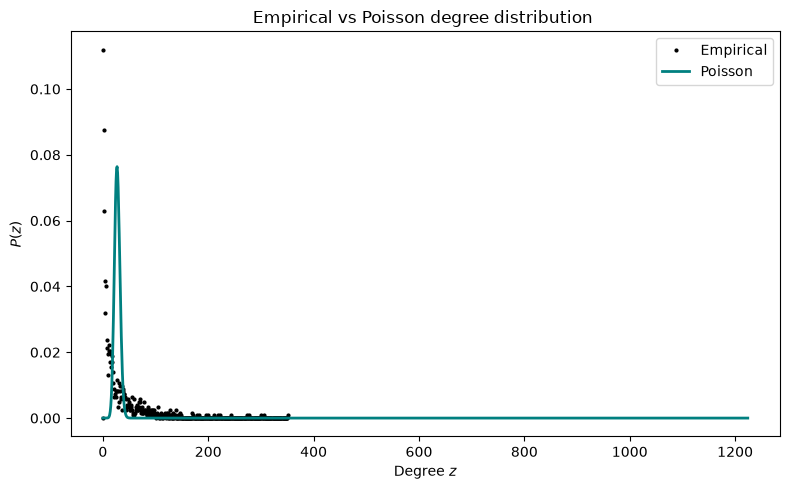

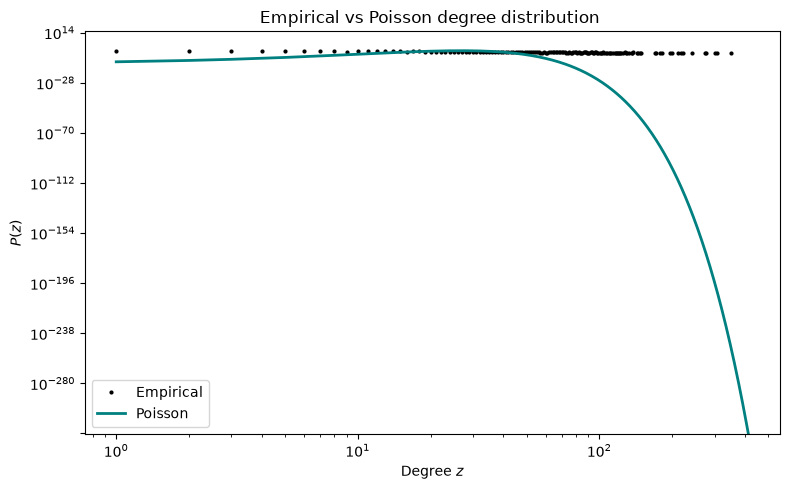

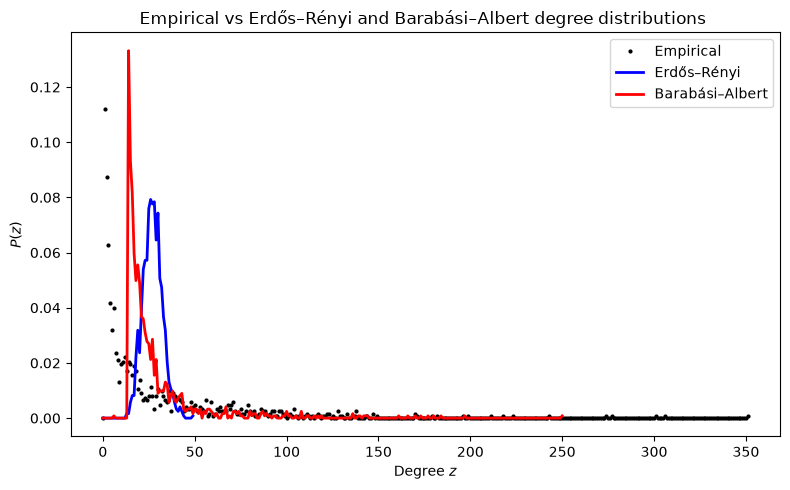

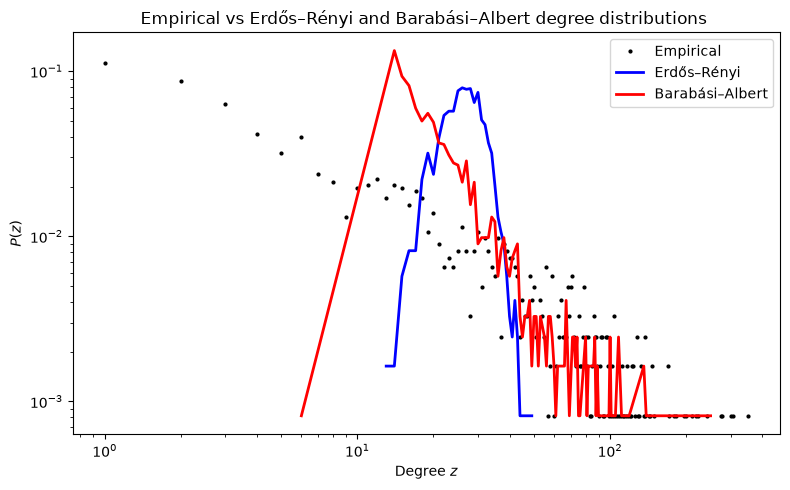

In [81]:
plot_empirical_vs_poisson(loglog=False)
plot_empirical_vs_poisson(loglog=True)
plot_empirical_vs_er_ba(loglog=False)
plot_empirical_vs_er_ba(loglog=True)